# Symmetrical Flow Matching

Toy Example of how the Symmetrical Flow matching objective can be used for sampling and one-step classification.

## Import Libraries

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from tqdm import tqdm, trange

In [2]:
!pip install seaborn

## Generate the Dataset

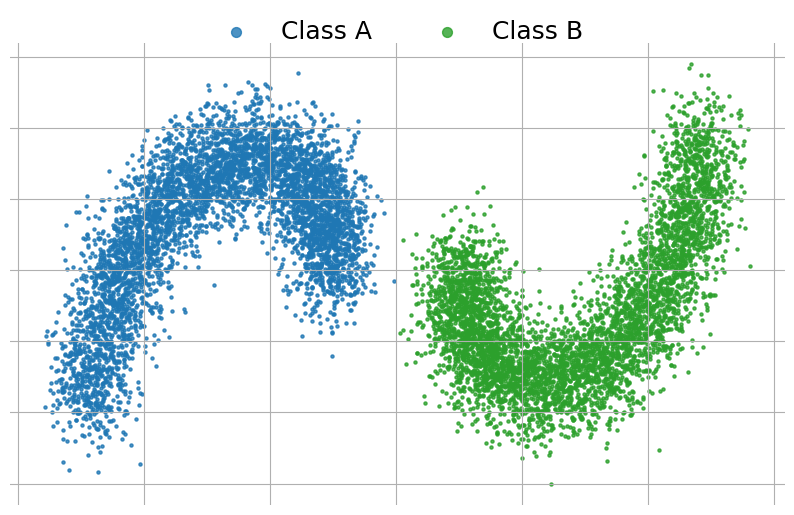

In [3]:
### Code based on https://bm371613.github.io/conditional-flow-matching/ ###

def plot_dataset(X, bins, Y=None, ax=None, verbose=True, **kwargs):
    '''
    Plot a 2D dataset.
    Args:
        X: torch.Tensor: The dataset to plot.
        bins: int: The number of bins to use for the histogram.
        Y: torch.Tensor: The labels of the dataset.
        ax: plt.Axes: The axes to plot on. If None, the current axes will be used.
        verbose: bool: Whether to show the axis labels.
        **kwargs: dict: Additional keyword arguments to pass to `ax.set`.
    '''
    if ax is None:
        ax = plt.gca()
    if Y is not None:
        ax.scatter(*X[Y == -1].T, color='#1f77b4', alpha=0.8, label='Class A', s=5)  # Modern blue
        ax.scatter(*X[Y == 1].T, color='#2ca02c', alpha=0.8, label='Class B', s=5)  # Modern green
        # 2 columns legend above plot
        legend = ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.10), fontsize=18, frameon=False)
        for handle in legend.legend_handles:
            handle.set_sizes([50])
    else:
        ax.scatter(*X.T, alpha=0.7, s=10)
    if verbose:
        ax.set_xlabel('Feature 0', fontsize=13)
        ax.set_ylabel('Feature 1', fontsize=13)
    #make ticks text larger
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set(**kwargs)
    ax.grid(True)
    ax.set_facecolor('white')  # White background
    # remove tick values on x and y axis
    ax.xaxis.set_tick_params(labelbottom=False)
    ax.yaxis.set_tick_params(labelleft=False)
    # remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # remove ticks
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)
    


def create_spirals(size: int = 100000, noise: float = 0.08, separation: float = 0.6):
    '''
    Create a dataset of size `size` of 2D points that have the shape of two interleaving spirals.
    Args:
        size: int: The number of points to generate.
        noise: float: The standard deviation of the Gaussian noise added to the data.
        separation: float: The distance to separate the two spirals.
    Returns:
        torch.Tensor: The generated dataset.
        torch.Tensor: The labels of the dataset.
    '''
    n_samples_per_spiral = size // 2
    theta = torch.sqrt(torch.linspace(0, 4 * torch.pi, n_samples_per_spiral))
    r = torch.linspace(0, 1, n_samples_per_spiral)
    x1 = r * torch.cos(theta)
    y1 = r * torch.sin(theta)
    x2 = r * torch.cos(theta + torch.pi)
    y2 = r * torch.sin(theta + torch.pi)
    spiral1 = torch.stack([x1, y1], dim=1) - torch.tensor([separation / 2, 0])
    spiral2 = torch.stack([x2, y2], dim=1) + torch.tensor([separation / 2, 0])
    X = torch.cat([spiral1, spiral2], dim=0)
    X += noise * torch.randn_like(X)
    y = torch.cat([-torch.ones(n_samples_per_spiral), torch.ones(n_samples_per_spiral)])
    return X, y

# Create the spirals dataset and plot it.
dataset, labels = create_spirals(10000)
fig = plt.figure(figsize=(10, 6))
plot_dataset(dataset, bins=64, Y=labels, verbose=False)


# MLP for Neural ODE

In [4]:
class ZeroToOneTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.dim = dim
        self.register_buffer('freqs', torch.arange(1, dim // 2 + 1) * torch.pi)
    
    def forward(self, t):
        emb = self.freqs * t[..., None]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class AutoEncoder(nn.Module):
    def __init__(self, in_features, out_features, hidden_dim=128, time_embedding_size=8):
        super().__init__()
        self.time_embedding = ZeroToOneTimeEmbedding(time_embedding_size)
        
        self.encoder1 = nn.Sequential(
            nn.Linear(in_features + time_embedding_size, hidden_dim),
            nn.LeakyReLU()
        )
        
        self.encoder2 = nn.Sequential(
            nn.Linear(hidden_dim + time_embedding_size, hidden_dim),
            nn.LeakyReLU()
        )
        
        self.bottleneck = nn.Sequential(
            nn.Linear(hidden_dim + time_embedding_size, hidden_dim),
            nn.LeakyReLU()
        )
        
        self.decoder1 = nn.Sequential(
            nn.Linear(hidden_dim + time_embedding_size, hidden_dim),
            nn.LeakyReLU()
        )
        
        self.decoder2 = nn.Sequential(
            nn.Linear(hidden_dim + time_embedding_size, out_features)
        )
        
    def forward(self, x, time):
        time_emb = self.time_embedding(time)
        x = torch.cat([x, time_emb], dim=-1)
        x = self.encoder1(x)
        x = torch.cat([x, time_emb], dim=-1)
        x = self.encoder2(x)
        x = torch.cat([x, time_emb], dim=-1)
        x = self.bottleneck(x)
        x = torch.cat([x, time_emb], dim=-1)
        x = self.decoder1(x)
        x = torch.cat([x, time_emb], dim=-1)
        x = self.decoder2(x)
        return x

## Label Dequantization

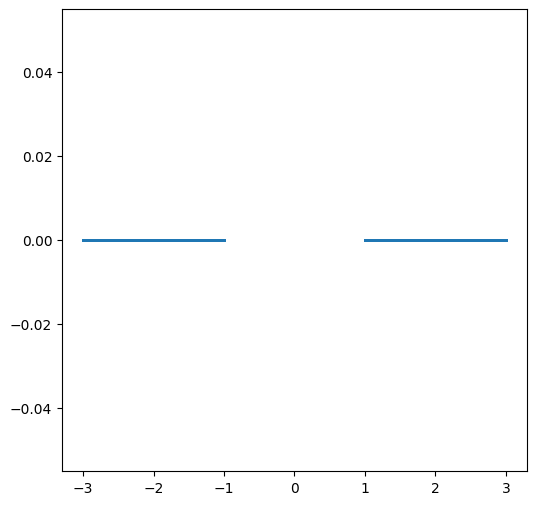

In [5]:
def dequantize_labels(Y):
    '''
    Dequantize the labels by adding uniform noise.
    Args:
        Y: torch.Tensor: The quantized labels.
    Returns:
        torch.Tensor: The dequantized labels.
    '''
    # convert 1d y to 2d by making the second dimension 0
    #Y = torch.stack([Y, torch.zeros_like(Y)], dim=1)
    # add uniform noise with range 0.5 
    Y = 2*Y + 2*(torch.rand_like(Y) - 0.5)
    return Y.unsqueeze(1)

y = dequantize_labels(labels)
fig = plt.figure(figsize=(6, 6))
plt.scatter(y[:], 0*y, s=1)

def quantize_labels(Y):
    '''
    Quantize the labels by rounding to the nearest integer.
    Args:
        Y: torch.Tensor: The dequantized labels.
    Returns:
        torch.Tensor: The quantized labels.
    '''
    # round to either -1 or 1
    Y = torch.sign(Y)
    return Y

## Train the Model

In [6]:
def symmetrical_flow_matching_loss(model, x, y):
    """The loss function for training flow matching generative models.

    Args:
        model: A PyTorch model instance that represents a 
        time-dependent score-based model.
        x: A mini-batch of training data.    
    """
    loss_fn = nn.MSELoss()
    sigma = 1e-4
    t = torch.rand(size=(x.shape[0],), device=x.device)  
    z_x = torch.randn_like(x)
    z_y = torch.randn_like(y)
    x_t = x*t[:, None] + z_x*(1-((1 - sigma)*t))[:, None]
    y_t = z_y*t[:, None] + y*(1-((1 - sigma)*t))[:, None]
    predicted_flow = model(torch.cat([x_t, y_t], dim=1), t)
    optimal_flow_x = x - z_x
    optimal_flow_y = z_y - y
    loss_x = loss_fn(predicted_flow[:,:2], optimal_flow_x)
    loss_y = loss_fn(predicted_flow[:,2:], optimal_flow_y)
    return 0.8*loss_x + 0.2*loss_y

def training_loop(model, n_steps, batch_size, lr):
    '''
    Train a model.
    Args:
        model: nn.Module: The model to train.
        n_steps: int: The number of training steps to take.
        batch_size: int: The number of samples in each batch.
        lr: float: The learning rate to use.
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    step_bar = trange(n_steps, desc='Steps')
    for step in step_bar:
        optimizer.zero_grad()
        batch, labels = create_spirals(size=batch_size)
        loss = symmetrical_flow_matching_loss(model, batch.to(device), dequantize_labels(labels).to(device))
        loss.backward()
        optimizer.step()
        if step % 400 == 0:
            step_bar.set_postfix({'loss': loss.item()})

model = AutoEncoder(in_features=3, out_features=3, hidden_dim=128, time_embedding_size=6)
training_loop(model, n_steps=40000, batch_size=100, lr=1e-3)

Steps: 100%|██████████| 40000/40000 [02:24<00:00, 277.13it/s, loss=0.617]


# Sample

100%|██████████| 20/20 [00:00<00:00, 202.41it/s]


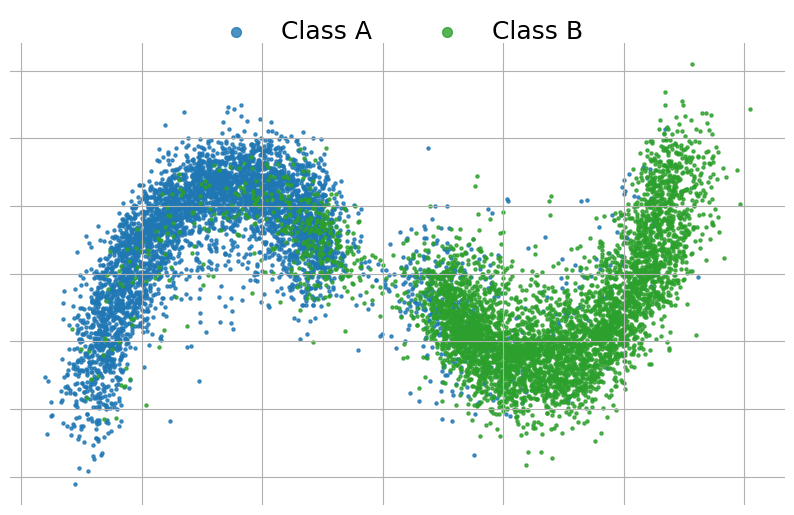

In [36]:
def plot_dataset(X, bins, Y=None, ax=None, verbose=True, **kwargs):
    '''
    Plot a 2D dataset.
    Args:
        X: torch.Tensor: The dataset to plot.
        bins: int: The number of bins to use for the histogram.
        Y: torch.Tensor: The labels of the dataset.
        ax: plt.Axes: The axes to plot on. If None, the current axes will be used.
        verbose: bool: Whether to show the axis labels.
        **kwargs: dict: Additional keyword arguments to pass to `ax.set`.
    '''
    if ax is None:
        ax = plt.gca()
    if Y is not None:
        ax.scatter(*X[Y == -1].T, color='#1f77b4', alpha=0.8, label='Class A', s=5)  # Modern blue
        ax.scatter(*X[Y == 1].T, color='#2ca02c', alpha=0.8, label='Class B', s=5)  # Modern green
        # 2 columns legend above plot
        legend = ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.10), fontsize=18, frameon=False)
        for handle in legend.legend_handles:
            handle.set_sizes([50])
    else:
        ax.scatter(*X.T, alpha=0.7, s=10)
    if verbose:
        ax.set_xlabel('Feature 0', fontsize=13)
        ax.set_ylabel('Feature 1', fontsize=13)
    #make ticks text larger
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set(**kwargs)
    ax.grid(True)
    ax.set_facecolor('white')  # White background
    # remove tick values on x and y axis
    ax.xaxis.set_tick_params(labelbottom=False)
    ax.yaxis.set_tick_params(labelleft=False)
    # remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # remove ticks
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False)

@torch.no_grad()
def sample_flow_matching(model, steps=100, num_samples=10000):
    '''
    Sample from the model using the flow matching method.
    Args:
        model: nn.Module: The model to sample from.
        steps: int: The number of steps to take.
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    t = torch.linspace(0, 1, steps+1)
    x = torch.randn(num_samples, 2)
    y = torch.cat([-torch.ones(num_samples//2), torch.ones(num_samples//2)], dim=0)
    x = torch.cat([x, dequantize_labels(y)], dim=1).to(device)
    step_size = 1. / steps
    for i in tqdm(range(steps)):
        x = x + step_size * model(x, torch.full((num_samples,), t[i]).to(x.device))
    return x[:,:2].cpu().detach(), y

# Sample from the model and plot the results.
samples, y = sample_flow_matching(model, steps=20)
fig = plt.figure(figsize=(10, 6))
plot_dataset(samples, bins=64, Y=y, verbose=False)

# Classification

In [ ]:
@torch.no_grad()
def classification_flow_matching(model, steps=100, num_samples=10000):
    '''
    Classify samples from the model using the flow matching method.
    Args:
        model: nn.Module: The model to sample from.
        steps: int: The number of steps to take.
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    t = torch.linspace(1, 0, steps+1)
    x_original, y_original = create_spirals(size=num_samples)
    y = torch.randn_like(y_original).unsqueeze(1)
    x = torch.cat([x_original, y], dim=1).to(device)
    step_size = 1. / steps
    for i in tqdm(range(steps)):
        x = x - step_size * model(x, torch.full((num_samples,), t[i]).to(x.device))
    return y_original, x[:,2].cpu().detach()

# Classify samples from the model and plot the results.
y_original, y_pred = classification_flow_matching(model, steps=25)
y_pred = quantize_labels(y_pred)
print(f'Accuracy: {(y_original == y_pred).float().mean().item()}')


100%|██████████| 25/25 [00:00<00:00, 221.87it/s]

Accuracy: 0.9060999751091003


: 